## Tests Rapides de Modèles par transfert Learning

Nous allons tester des modeles entraine sur Imagenet et Open Image
https://github.com/google/automl/tree/master/efficientdet
EfficientDet / EfficientNet (Google)

In [59]:
import psutil
import tensorflow as tf
from tensorflow.keras import layers

import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.applications import VGG16






In [11]:
print("version tensorflow: {}".format(tf.__version__))
print("Mémoire totale :", psutil.virtual_memory().total / (1024**3), "GB")
print("Utilisation CPU :", psutil.cpu_percent(interval=1), "%")

for disk in psutil.disk_partitions():
    print("Type :", disk.fstype)
    print("Monté sur :", disk.mountpoint)
    print("-" * 30)

version tensorflow: 2.19.0
Mémoire totale : 15.691375732421875 GB
Utilisation CPU : 39.2 %
Type : NTFS
Monté sur : C:\
------------------------------


## MobileNetV2

Les réseaux neuronaux convolutifs ont démontré des performances remarquables dans des tâches de vision par ordinateur telles que la classification d'images, la détection d'objets et la segmentation sémantique. Cependant, les architectures CNN traditionnelles, comme VGG, ResNet ou Inception, sont souvent caractérisées par un grand nombre de paramètres (nous les testerons ...) et une complexité computationnelle élevée. Cette complexité les rend gourmands en ressources et difficilement déployables sur des appareils à ressources limitées.

C'est précisément là que MobileNet intervient. Développé par Google, MobileNet représente une famille d'architectures de réseaux neuronaux convolutifs conçues spécifiquement pour des applications sur appareils mobiles et embarqués, où la consommation d'énergie, la latence et la taille du modèle sont des contraintes critiques. L'objectif fondamental de MobileNet est de permettre le déploiement de modèles de vision par ordinateur sophistiqués sur des plateformes telles que les smartphones, les drones, les véhicules autonomes, les dispositifs IoT et d'autres systèmes edge computing, sans compromettre significativement la précision.

La philosophie derrière MobileNet est de concevoir des réseaux qui sont à la fois légers  et efficaces
En utilisant des poids pré-entraînés sur ImageNet, MobileNetV2 peut reconnaître des formes et textures génériques dès les premières couches, avant d'être adapté aux particularités notre dataset. En combinant sa légèreté et son efficacité avec un fine-tuning sur nos images, on peut obtenir un modèle performant qui conserve une bonne précision sans exiger une puissance de calcul excessive.


### 1. changement des images : 10 races

In [12]:
images_dir = '../data/images_transf_256x256'  
list_dir = '../data/lists'  

df_train, df_test = image_search.load_train_test_split_mat(
    images_dir=images_dir,
    list_dir=list_dir,
    max_races=10
)


### 2. Conversion en tableaux NumPy

In [13]:
X_train, y_train = image_search.images_to_numpy(df_train)
X_test, y_test = image_search.images_to_numpy(df_test)
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")


X_train shape: (1000, 256, 256, 3), dtype: uint8
X_test shape: (919, 256, 256, 3), dtype: uint8


### 3.Encodage des labels

In [14]:
# Conversion des labels en int
# LabelEncoder assigne un numéro unique à chaque classe
label_encoder = sklearn.preprocessing.LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Transformation des labels entiers en représentation one-hot
# Nécessaire pour  softmax en sortie
# Format one-hot : [1, 0, 0] = classe 0, [0, 1, 0] = classe 1, etc.

y_train_cat = tf.keras.utils.to_categorical(y_train_int)
y_test_cat = tf.keras.utils.to_categorical(y_test_int)


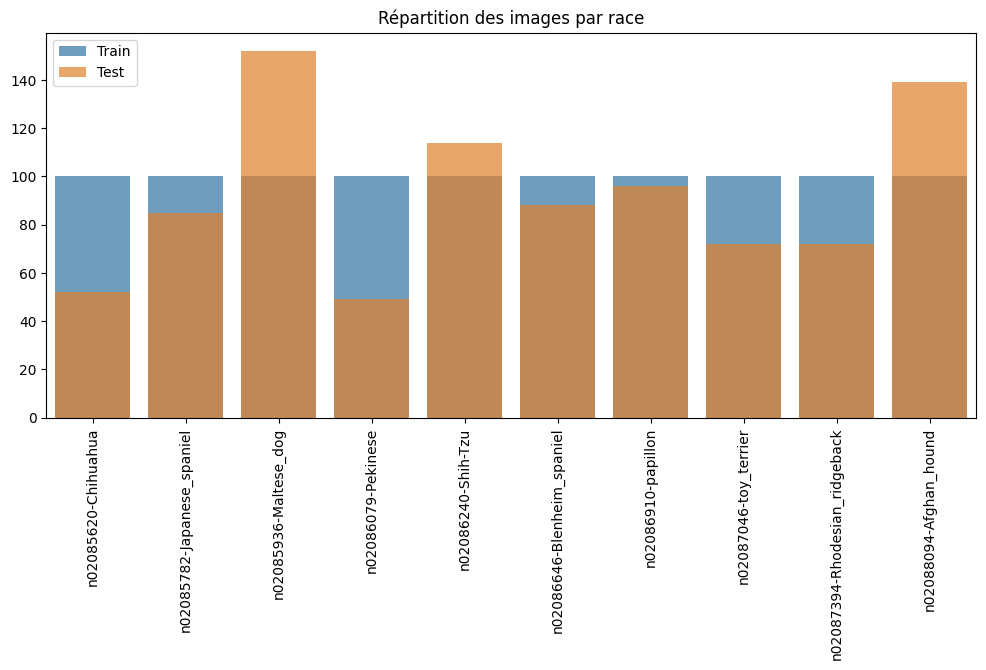

In [15]:
train_counts = {cls: sum(y_train == cls) for cls in np.unique(y_train)}
test_counts = {cls: sum(y_test == cls) for cls in np.unique(y_test)}
plt.figure(figsize=(12, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), alpha=0.7, label="Train")
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), alpha=0.7, label="Test")
plt.xticks(rotation=90)
plt.legend()
plt.title("Répartition des images par race")
plt.show()

### Initialisation du modéle

In [16]:

# Charge le modèle MobileNetV2 pré-entraîné sur ImageNet.
# 'include_top=False' exclut les couches de classification originales.
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=X_train.shape[1:])

# Gèle les poids du modèle de base. Cela empêche leur modification pendant l'entraînement initial,
# utilisant ses capacités d'extraction de caractéristiques sans les altérer.
base_model.trainable = False


C:\Users\HP\AppData\Local\Temp\ipykernel_10880\2790652016.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=X_train.shape[1:])


In [18]:

# Construction du modèle complet
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Réduction de la dimension spatiale
    layers.Dropout(0.3),  # Prévention du sur-apprentissage
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),  # Normalisation pour stabiliser l'entraînement
    layers.Dropout(0.3),
    layers.Dense(len(label_encoder.classes_), activation='softmax')  
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks 

# Définit un callback pour l'arrêt anticipé de l'entraînement.
# Arrête si 'val_loss' ne s'améliore pas pendant 3 époques et restaure les meilleurs poids.
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entraînement du modèle
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/20
32/32 - 50s - 2s/step - accuracy: 0.1570 - loss: 2.8591 - val_accuracy: 0.2002 - val_loss: 2.2294
Epoch 2/20
32/32 - 36s - 1s/step - accuracy: 0.2380 - loss: 2.2648 - val_accuracy: 0.2122 - val_loss: 2.3185
Epoch 3/20
32/32 - 37s - 1s/step - accuracy: 0.2940 - loss: 2.1092 - val_accuracy: 0.2622 - val_loss: 2.0980
Epoch 4/20
32/32 - 38s - 1s/step - accuracy: 0.3300 - loss: 1.9512 - val_accuracy: 0.3493 - val_loss: 1.8378
Epoch 5/20
32/32 - 42s - 1s/step - accuracy: 0.3550 - loss: 1.7979 - val_accuracy: 0.3569 - val_loss: 1.8214
Epoch 6/20
32/32 - 38s - 1s/step - accuracy: 0.3930 - loss: 1.7324 - val_accuracy: 0.3711 - val_loss: 1.7845
Epoch 7/20
32/32 - 35s - 1s/step - accuracy: 0.4060 - loss: 1.6807 - val_accuracy: 0.3983 - val_loss: 1.7691
Epoch 8/20
32/32 - 33s - 1s/step - accuracy: 0.4500 - loss: 1.5720 - val_accuracy: 0.4113 - val_loss: 1.7131
Epoch 9/20
32/32 - 34s - 1s/step - accuracy: 0.4820 - loss: 1.5093 - val_accuracy: 0.3787 - val_loss: 1.7383
Epoch 10/20
32/32 -

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 644ms/step


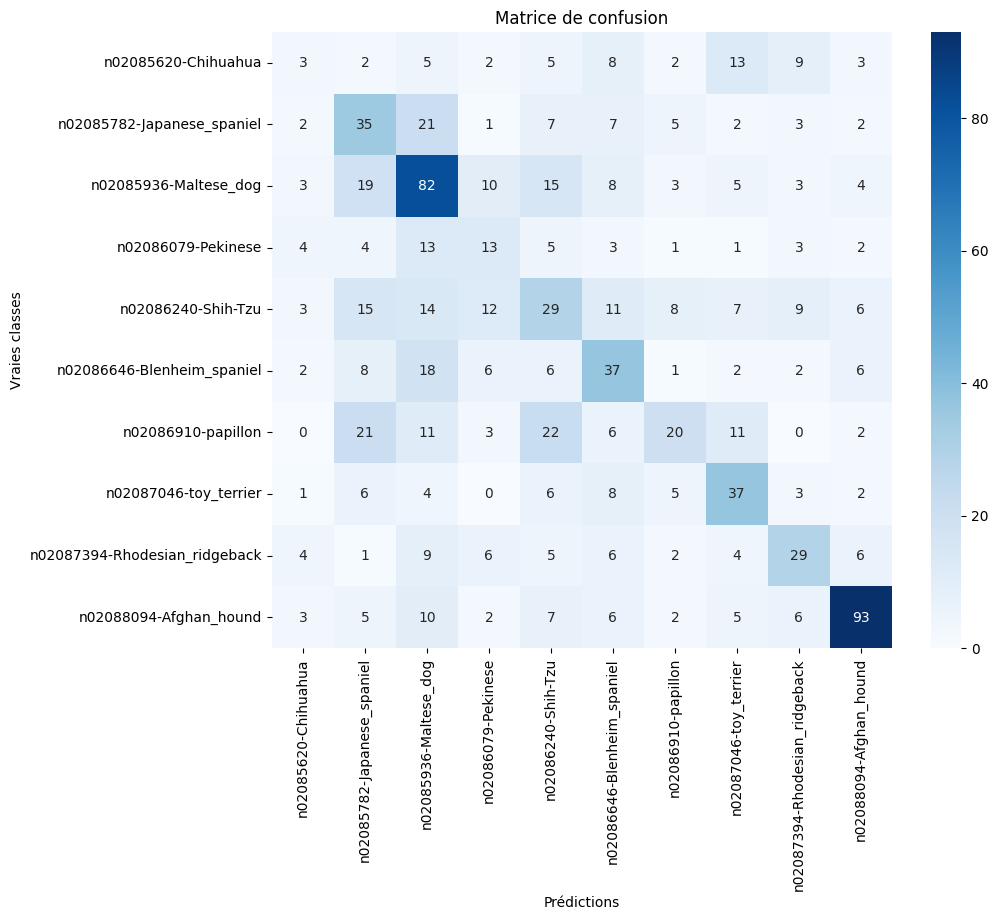

In [24]:
# Prédictions du modèle
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes
y_true_classes = np.argmax(y_test_cat, axis=1)  # Convertir les labels one-hot en classes

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()

### Conclusion MObilNetV2

Le modèle montre une progression claire sur l'ensemble d'entraînement, avec une précision qui passe de 35,5 % à environ 49,3 %. Cela signifie qu'il parvient à mieux identifier les images au fil du temps. Cependant, la précision sur le jeu de validation reste relativement stable autour de 37 à 41 %, sans réelle amélioration à partir de la huitième époque. Cette stagnation, combinée à une perte de validation qui ne diminue pas de façon significative, indique un début de surapprentissage : le modèle apprend les exemples d'entraînement mais ne généralise pas aussi bien sur les exemples qu'il n'a jamais vus.

L’examen de la matrice de confusion révèle plusieurs éléments importants. Certaines classes sont très bien apprises par le modèle. Par exemple, la race "Maltese_dog" est correctement identifiée dans 82 cas, et la race "Afghan_hound" dans 93 cas. Cela suggère que les caractéristiques visuelles de ces chiens sont bien captées par le réseau.

En revanche, plusieurs races proches sont régulièrement confondues entre elles. C’est le cas notamment des races "Japanese_spaniel", "Blenheim_spaniel", "Papillon" ou encore "Shih-Tzu", qui sont toutes des chiens de petite taille avec un pelage long et parfois un museau court. Le modèle semble avoir du mal à distinguer ces caractéristiques fines, ce qui conduit à des confusions fréquentes.

Enfin, la race "Rhodesian_ridgeback", qui est un chien de grande taille, est elle aussi souvent confondue avec des races de gabarit bien différent. Cela montre que le modèle n'exploite pas encore pleinement les indices de forme ou de proportions dans les images.

Le modèle est donc capable d’apprendre à différencier certaines races, mais ses performances sont limitées par la complexité visuelle des données. Le surapprentissage semble apparaître après quelques époques, ce qui suggère qu’une régularisation ou une augmentation des données pourrait être bénéfique. Par ailleurs, les confusions fréquentes entre races visuellement proches indiquent que le modèle gagnerait en efficacité en s’appuyant sur une architecture plus profonde. Ce type de solution pourrait permettre d'extraire des représentations visuelles plus riches et plus discriminantes.

## MobilNetV2 version amélioré avec data-augmentation

Nous allons recharger les images pour eviter les vas et viens à chaque restart du kernel

In [33]:
images_dir = '../data/images_transf_256x256'  
list_dir = '../data/lists'  

df_train, df_test = image_search.load_train_test_split_mat(
    images_dir=images_dir,
    list_dir=list_dir,
    max_races=10
)
X_train, y_train = image_search.images_to_numpy(df_train)
X_test, y_test = image_search.images_to_numpy(df_test)
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")


X_train shape: (1000, 256, 256, 3), dtype: uint8
X_test shape: (919, 256, 256, 3), dtype: uint8


In [ ]:
IMAGE_SIZE = X_train.shape[1]  
BATCH_SIZE = 32
EPOCHS = 25
DROPOUT_RATE = 0.2
NUM_CLASSES = len(label_encoder.classes_)

# Normalisation des images (valeurs entre 0 et 1)
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0
#X_train_resized = resize_array(X_train, target_size=IMAGE_SIZE)
#X_test_resized = resize_array(X_test, target_size=IMAGE_SIZE)


In [35]:
# Définition d'un pipeline d'augmentation de données
# Ces transformations ne modifient pas les images originales, elles sont appliquées à la volée
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")


In [36]:
# Chargement de MobileNetV2 sans les couches de classification (include_top=False)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=X_train.shape[1:], 
    include_top=False,
    weights='imagenet'
)

# On gèle les poids de ce modèle de base pour ne pas les entraîner dans un premier temps
base_model.trainable = False


C:\Users\HP\AppData\Local\Temp\ipykernel_10880\1350441591.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [37]:
# Construction du modèle complet avec data augmentation
model = tf.keras.Sequential([
    data_augmentation,                # Applique l'augmentation à chaque batch
    base_model,                       
    tf.keras.layers.Conv2D(32, 3, activation='relu'), 
    tf.keras.layers.Dropout(DROPOUT_RATE),             # Dropout pour éviter le sur-apprentissage
    tf.keras.layers.GlobalAveragePooling2D(),          # Réduction de dimension
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
# Callbacks pour arrêter l'entraînement si la performance se stabilise
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
# Entraînement du modèle
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/25
32/32 - 51s - 2s/step - accuracy: 0.6590 - loss: 1.0732 - val_accuracy: 0.9053 - val_loss: 0.3152
Epoch 2/25
32/32 - 39s - 1s/step - accuracy: 0.8990 - loss: 0.3086 - val_accuracy: 0.9217 - val_loss: 0.2661
Epoch 3/25
32/32 - 39s - 1s/step - accuracy: 0.9220 - loss: 0.2242 - val_accuracy: 0.9249 - val_loss: 0.2661
Epoch 4/25
32/32 - 39s - 1s/step - accuracy: 0.9370 - loss: 0.1761 - val_accuracy: 0.9151 - val_loss: 0.2832
Epoch 5/25
32/32 - 43s - 1s/step - accuracy: 0.9300 - loss: 0.2001 - val_accuracy: 0.9227 - val_loss: 0.2976
Epoch 6/25
32/32 - 39s - 1s/step - accuracy: 0.9460 - loss: 0.1801 - val_accuracy: 0.9140 - val_loss: 0.3119


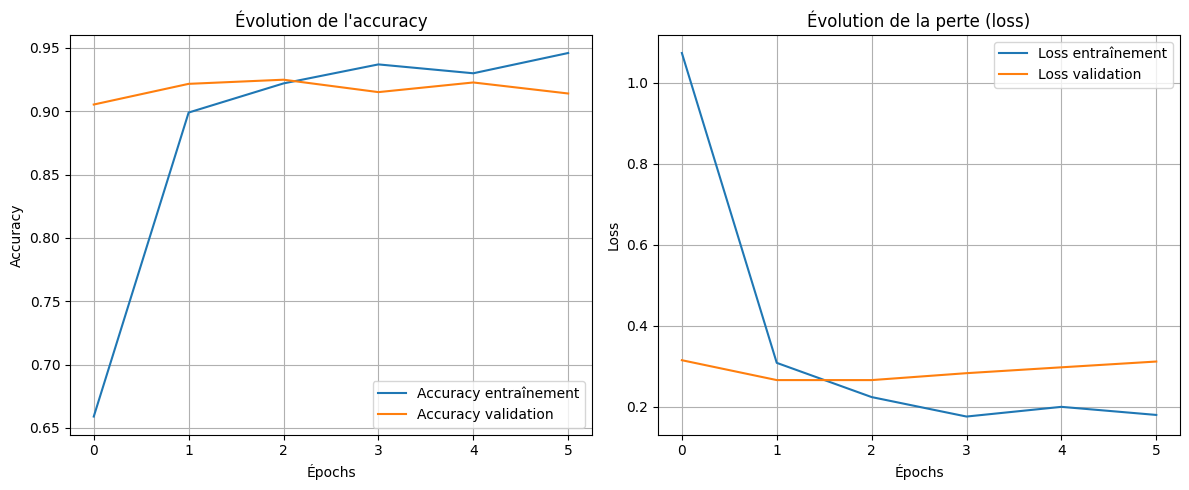

In [41]:

# Tracer l'évolution de l'accuracy 
plt.figure(figsize=(12, 5))

# Sous-graphique 1 : Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy entraînement')
plt.plot(history.history['val_accuracy'], label='Accuracy validation')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.title("Évolution de l'accuracy")
plt.legend()
plt.grid(True)

# Sous-graphique 2 : Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')
plt.xlabel('Épochs')
plt.ylabel('Loss')
plt.title("Évolution de la perte (loss)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 643ms/step


<Figure size 1000x1000 with 0 Axes>

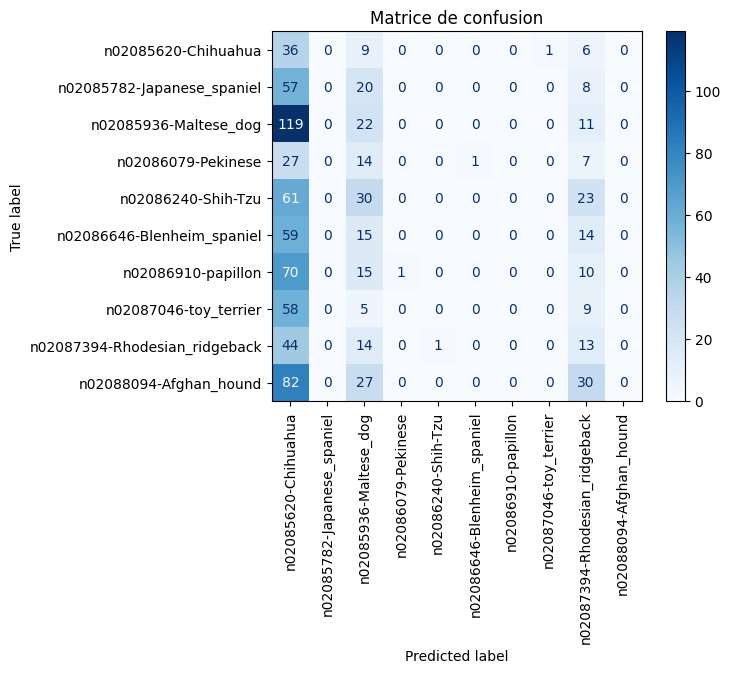

In [43]:
# Prédiction sur les données de test

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # classe prédite

# Matrice de confusion
cm = confusion_matrix(y_test_int, y_pred)
labels = label_encoder.classes_  # noms des classes

# Affichage
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='d')
plt.title("Matrice de confusion")
plt.grid(False)
plt.show()


## CONCLUSION MobilNetV2 amélioré
---
## Conclusion et Perspectives

 Nous avons constaté que notre modèle, bien qu'atteignant une précision de validation de 91,4 %  montrait des signes précoces de surapprentissage comme en témoigne l'augmentation de la perte de validation. L'analyse de la matrice de confusion révéle un biais significatif, avec une sur-prédiction de la race Maltese et une incapacité à reconnaître d'autres races.

Pour l'avenir, nous devrons  aller au-delà de la simple exactitude pour évaluer les performances de notre modèle. Nous utiliserons des métriques plus robustes telles que la précision, le rappel et le F1-score, qui nous offriront une vision plus nuancée et plus fidèle des capacités réelles du modèle à identifier correctement chaque race de chien, en particulier celles qui sont sous-représentées. Cela nous permettra de mieux cibler les améliorations nécessaires et de construire un modèle plus équilibré et performant.

## MobilNetV2 amélioré ++  avec métriques diversifié

In [52]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=X_train_scaled.shape[1:]
)
base_model.trainable = False  # gèle les couches du modèle pré-entraîné

model = models.Sequential([
    base_model,
    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


C:\Users\HP\AppData\Local\Temp\ipykernel_10880\1983741021.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


weights='imagenet' : Charge des poids pré-entraînés sur ImageNet

In [54]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


In [55]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/25
32/32 - 47s - 1s/step - accuracy: 0.7090 - loss: 0.9098 - precision: 0.8336 - recall: 0.5760 - val_accuracy: 0.7911 - val_loss: 0.6296 - val_precision: 0.8875 - val_recall: 0.6779
Epoch 2/25
32/32 - 37s - 1s/step - accuracy: 0.9130 - loss: 0.3168 - precision: 0.9400 - recall: 0.8610 - val_accuracy: 0.9119 - val_loss: 0.3302 - val_precision: 0.9462 - val_recall: 0.8618
Epoch 3/25
32/32 - 40s - 1s/step - accuracy: 0.9290 - loss: 0.2524 - precision: 0.9475 - recall: 0.9020 - val_accuracy: 0.9119 - val_loss: 0.2981 - val_precision: 0.9441 - val_recall: 0.8814
Epoch 4/25
32/32 - 40s - 1s/step - accuracy: 0.9510 - loss: 0.1685 - precision: 0.9642 - recall: 0.9430 - val_accuracy: 0.9217 - val_loss: 0.2856 - val_precision: 0.9488 - val_recall: 0.8868
Epoch 5/25
32/32 - 38s - 1s/step - accuracy: 0.9710 - loss: 0.1206 - precision: 0.9727 - recall: 0.9610 - val_accuracy: 0.9173 - val_loss: 0.2652 - val_precision: 0.9253 - val_recall: 0.9032
Epoch 6/25
32/32 - 39s - 1s/step - accuracy: 

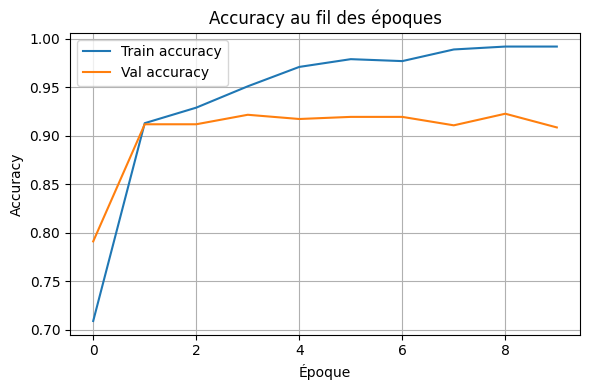

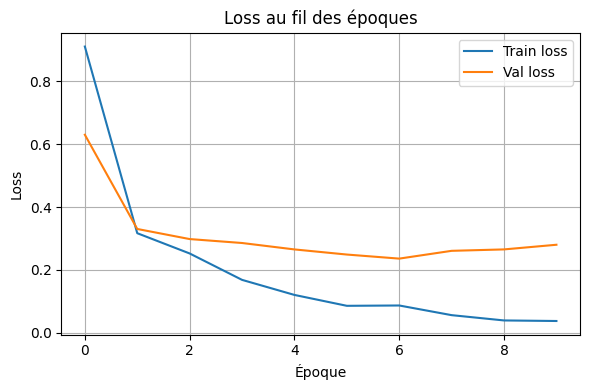

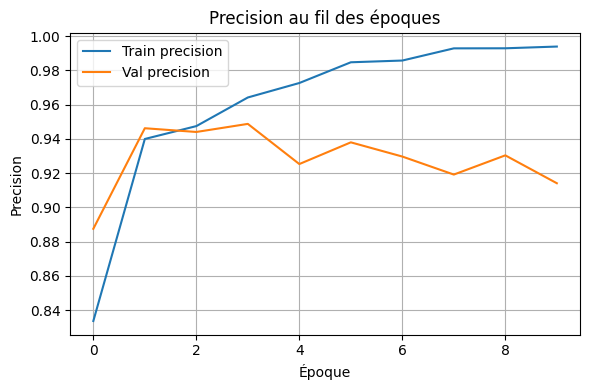

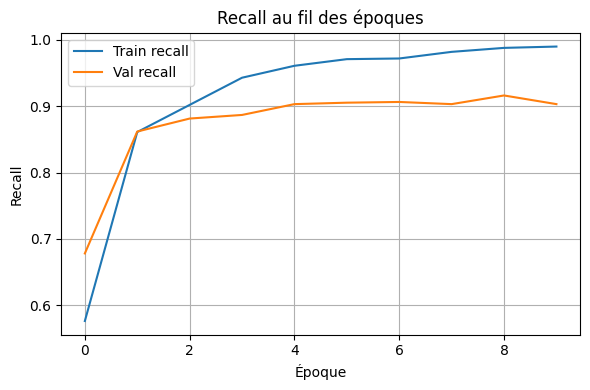

In [56]:

def plot_metrics(history):
    metrics_list = ['accuracy', 'loss', 'precision', 'recall']
    for metric in metrics_list:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} au fil des époques')
        plt.xlabel('Époque')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_metrics(history)


29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 629ms/step


<Figure size 1000x800 with 0 Axes>

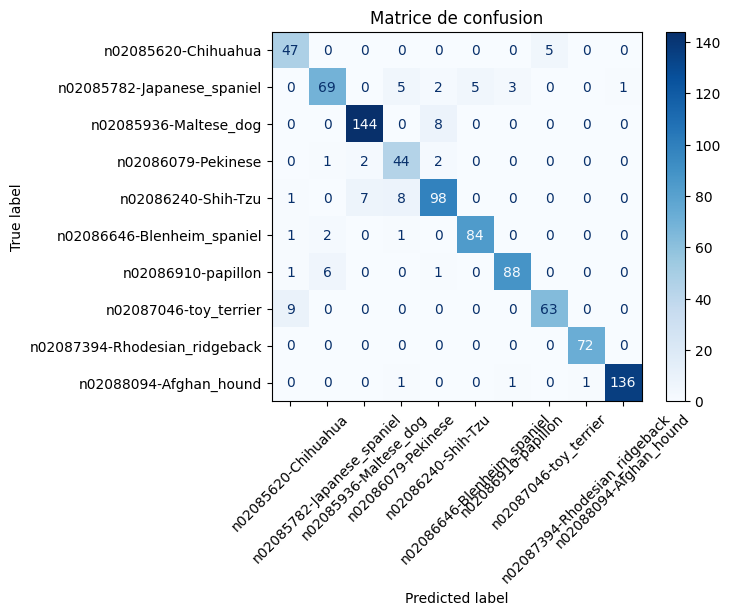

Rapport de classification :
                               precision    recall  f1-score   support

          n02085620-Chihuahua       0.80      0.90      0.85        52
   n02085782-Japanese_spaniel       0.88      0.81      0.85        85
        n02085936-Maltese_dog       0.94      0.95      0.94       152
           n02086079-Pekinese       0.75      0.90      0.81        49
           n02086240-Shih-Tzu       0.88      0.86      0.87       114
   n02086646-Blenheim_spaniel       0.94      0.95      0.95        88
           n02086910-papillon       0.96      0.92      0.94        96
        n02087046-toy_terrier       0.93      0.88      0.90        72
n02087394-Rhodesian_ridgeback       0.99      1.00      0.99        72
       n02088094-Afghan_hound       0.99      0.98      0.99       139

                     accuracy                           0.92       919
                    macro avg       0.91      0.91      0.91       919
                 weighted avg       0.92      0

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prédictions sur X_test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_int

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matrice de confusion")
plt.show()

# Rapport de classification : precision, recall, f1
print("Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,381,824 (12.90 MB)

 Trainable params: 374,506 (1.43 MB)

 Non-trainable params: 2,258,304 (8.61 MB)

 Optimizer params: 749,014 (2.86 MB)

## Comparaison entre les deux dernies models MobilNetV2


Les deux modèles partagent une approche commune : ils tirent parti du transfer learning en utilisant un modèle de base MobileNetV2 pré-entraîné sur ImageNet, dont les poids sont initialement gelés

Cependant, des distinctions importantes apparaissent dans leur architecture . Le modèle 1 intègre  une couche de data augmentation directement au début de son architecture. 

En revanche, le modèle 2 ne posséde pas de couche de data augmentation .La différence majeure réside dans la complexité de sa tête de classification. Le modèle 2 ajoute des couches de **Batch Normalization** après la couche convolutive et après une couche Dense supplémentaire de 128 neurones. La Batch Normalization est une technique  qui aide à stabiliser et à accélérer l'entraînement des réseaux profonds en normalisant les activations des couches, rendant le modèle plus robuste. De plus, le modèle 2 inclut une couche Dense intermédiaire, ce qui lui permet potentiellement d'apprendre des représentations plus complexes avant la classification finale. Enfin, le modèle 2 compile avec des métriques d'évaluation plus détaillées (précision et rappel en plus de l'exactitude), offrant une vue plus complète des performances du modèle, particulièrement utile pour les jeux de données déséquilibrés.

>Conclusion
Ainsi, le modèle 2 démontre que l'ajout de **Batch Normalization** et d'une **couche Dense intermédiaire** améliore la stabilité et la capacité du réseau à apprendre des représentations plus complexes. Son architecture plus profonde permet une meilleure distinction entre les classes, ce qui se traduit par une précision accrue. L'absence de **data augmentation** dans ce modèle ne semble pas avoir affecté ses performances, suggérant que le dataset était suffisamment diversifié ou que les transformations du modèle 1 n'étaient pas optimales.
Nous allons verifier cela avec le dataset global



## Remarque importante ImageNet et Standford dogs

MobileNetV2, pré-entraîné sur ImageNet, possède une capacité de reconnaissance visuelle des chiens mais ne distingue pas directement les races spécifiques. Étant donné que Stanford Dogs est un sous-ensemble d'ImageNet, le modèle dispose déjà d'une base solide en matière de caractéristiques générales, telles que la texture du pelage, la morphologie et les proportions. Cependant, la classification fine-grainée des races nécessite une adaptation des couches supérieures du réseau.

Le modèle pré-entraîné a appris des motifs globaux utiles pour la reconnaissance des animaux, mais pour obtenir une identification précise des races, il est important  d'affiner l'apprentissage en réentraînant certaines couches. Cela permet au modèle de se concentrer sur les différences subtiles entre les races, comme la forme des oreilles, la couleur du pelage ou la structure faciale. Une approche optimale consisterait à utiliser le modèle pré-entraîné pour conserver les caractéristiques générales et à dégeler progressivement certaines couches afin d'améliorer la spécialisation sur Stanford Dogs.

L'intégration d'une stratégie de fine-tuning bien ajustée pourrait considérablement améliorer la précision de classification. Il serait pertinent d'analyser les performances du modèle sur chaque classe pour identifier les éventuelles confusions et ajuster les paramètres en conséquence. Tester différentes architectures plus profondes, comme InceptionResNetV2, pourrait également offrir des résultats plus performants sur ce type de classification fine. Une analyse des erreurs et une adaptation progressive du modèle permettraient d'optimiser l'identification des races de manière plus efficace.


## Conclusion MobilNet 

Les résultats globaux ont été très prometteurs, avec une accuracy d'entraînement et de validation atteignant respectivement environ 99% et 92%. La précision et le rappel en validation étaient également supérieurs à 90%

l'analyse de la matrice de confusion a révélé des nuances importantes. Si le modèle classifie excellemment la majorité des races , il rencontre des difficultés majeures avec certaines d'entre elles. Le Japanese spaniel est systématiquement mal classé, et des confusions notables persistent entre races visuellement proches comme le Pekinese/Shih-Tzu et le Chihuahua/Rhodesian Ridgeback, suggérant des similarités morphologiques ou des déséquilibres dans les données.

Le modéle est globalement bon

## VGG16

Dans cette partie nous optons pour VGG16. VGG16 est connu pour sa profondeur et l'utilisation répétée de couches convolutives de petite taille (3x3), ce qui lui permet de capturer des caractéristiques hiérarchiques très riches. Comme MobileNetV2, nous l'utiliserons comme extracteur de caractéristiques en gelant ses poids dans un premier temps.

> Un probléme que nous n'avons pas pris en compte est de resize tous les images en fonction de la tailles des images qui ont servis à entrainer le modéle . Ce detail sera corrigé dans les 0.5 notebooks

In [60]:
base_model_vgg = VGG16(
    input_shape=X_train_scaled.shape[1:],
    include_top=False,
    weights='imagenet'
)

# On gèle les poids de ce modèle de base pour ne pas les entraîner initialement
base_model_vgg.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [61]:

# Construction du modèle complet avec une tête de classification plus robuste
model_vgg = models.Sequential([
    base_model_vgg,
    layers.Flatten(), # VGG16 se termine par des couches convolutives, on a besoin de Flatten avant les Dense
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [62]:

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Callbacks pour arrêter l'entraînement si la performance se stabilise
early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=5, # Augmentons la patience pour un modèle potentiellement plus lent à converger
    restore_best_weights=True
)


In [ ]:

# Entraînement du modèle
history_vgg = model_vgg.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_vgg],
    verbose=2
)

Epoch 1/25
32/32 - 509s - 16s/step - accuracy: 0.4230 - loss: 1.8139 - precision: 0.5459 - recall: 0.3030 - val_accuracy: 0.3351 - val_loss: 4.6469 - val_precision: 0.3656 - val_recall: 0.3166
Epoch 2/25
32/32 - 517s - 16s/step - accuracy: 0.8130 - loss: 0.5927 - precision: 0.8966 - recall: 0.7110 - val_accuracy: 0.3493 - val_loss: 3.6624 - val_precision: 0.3710 - val_recall: 0.3319
Epoch 3/25
32/32 - 429s - 13s/step - accuracy: 0.9280 - loss: 0.2638 - precision: 0.9559 - recall: 0.8880 - val_accuracy: 0.4755 - val_loss: 2.3969 - val_precision: 0.5394 - val_recall: 0.4472
Epoch 4/25
32/32 - 447s - 14s/step - accuracy: 0.9630 - loss: 0.1458 - precision: 0.9702 - recall: 0.9430 - val_accuracy: 0.5386 - val_loss: 1.7285 - val_precision: 0.5876 - val_recall: 0.4853
Epoch 5/25
32/32 - 441s - 14s/step - accuracy: 0.9810 - loss: 0.0820 - precision: 0.9849 - recall: 0.9770 - val_accuracy: 0.5201 - val_loss: 1.7173 - val_precision: 0.5924 - val_recall: 0.4777
Epoch 6/25
32/32 - 448s - 14s/step 

In [ ]:
model.summary()

In [ ]:

def plot_metrics(history):
    metrics_list = ['accuracy', 'loss', 'precision', 'recall']
    for metric in metrics_list:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} au fil des époques')
        plt.xlabel('Époque')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_metrics(history)


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prédictions sur X_test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_int

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matrice de confusion")
plt.show()

# Rapport de classification : precision, recall, f1
print("Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
